# Step 1 — Exploratory Data Analysis (EDA)
**Used Car Price Predictor · AI Developer Project**

---

## Purpose of this notebook

Before any model can be trained, we need to deeply understand the data:
- What does each column represent?
- Are the distributions well-behaved or heavily skewed?
- Which features are correlated with the target (`selling_price`)?
- Are there outliers that could distort our models?

> **This notebook is self-contained and narrative.** Every code cell is followed by a markdown cell that interprets the output and justifies decisions. It serves as both the exploratory analysis and the documentation for Step 1.

---

## Dataset overview

| Column | Type | Description |
|---|---|---|
| `year` | Numeric | Year the car was first registered |
| `km_driven` | Numeric | Total mileage in kilometres |
| `fuel` | Categorical | Fuel type (Petrol, Diesel, CNG, LPG, Electric) |
| `seller_type` | Categorical | Who is selling (Individual, Dealer, Trustmark Dealer) |
| `transmission` | Categorical | Manual or Automatic |
| `owner` | Ordinal | Number of previous owners (1st, 2nd, 3rd, 4th+) |
| `selling_price` | Numeric | **Target variable** — the price we want to predict |


---
## 1. Imports & Data Loading

We use `pandas` for data manipulation, `seaborn` and `matplotlib` for visualization.
`%matplotlib inline` ensures plots appear directly inside the notebook.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='muted')

RAW_PATH = Path('../data/raw/car-price-data.csv')
df = pd.read_csv(RAW_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Dataset loaded: 4,340 rows x 8 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,"2,007.00",60000,"70,000.00",Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,"2,007.00",135000,"50,000.00",Petrol,Individual,Manual,NaN
2,Hyundai Verna 1.6 SX,"2,012.00",600000,"100,000.00",Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,"2,017.00",250000,"46,000.00",Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,"2,014.00",450000,"141,000.00",Diesel,Individual,Manual,Second Owner


### Structure check

| Check | Why it matters |
|---|---|
| `shape` | Confirms the file loaded completely |
| `head()` | First sanity check — are column names correct, values sensible? |
| `dtypes` | Detects columns loaded as wrong types (e.g., numeric read as string) |
| `isnull().sum()` | Flags missing data that must be handled before training |
| `duplicated().sum()` | Duplicate rows inflate training data and bias model evaluation |


In [2]:
print('=== Column types ===')
print(df.dtypes)
print('\n=== Missing values ===')
print(df.isnull().sum())
print(f'\n=== Duplicate rows ===  {df.duplicated().sum()}')


=== Column types ===
name                 str
year             float64
selling_price      int64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object

=== Missing values ===
name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64

=== Duplicate rows ===  635


---
## 2. Descriptive Statistics

Descriptive statistics give us the *shape* of each variable before we visualize it.
We compute **mean**, **median**, **std**, **min/max** for numeric columns and **value counts** for categoricals.


In [3]:
num_cols = ['selling_price', 'year', 'km_driven']
desc = df[num_cols].describe().T
desc['median'] = df[num_cols].median()
desc['skewness'] = df[num_cols].skew()
desc[['count','mean','median','std','min','25%','75%','max','skewness']]


,count,mean,median,std,min,25%,75%,max,skewness
selling_price,"4,340.00","504,127.31","350,000.00","578,548.74","20,000.00","208,749.75","600,000.00","8,900,000.00",4.89
year,"4,297.00","2,013.09","2,014.00",4.22,"1,992.00","2,011.00","2,016.00","2,020.00",-0.84
km_driven,"4,167.00","66,237.20","60,000.00","46,635.46",1.00,"35,000.00","90,000.00","806,599.00",2.71


### Reading the numeric summary

| Column | Key insight |
|---|---|
| `selling_price` | High **skewness** (> 1) indicates a long right tail — most cars are cheap, a few are very expensive. Typical for used-car markets. |
| `km_driven` | Also right-skewed. The median is far below the mean, pulled up by high-mileage outliers. |
| `year` | Relatively concentrated — most cars are < 10 years old. Min/max reveals the oldest and newest listings. |

> **Skewness > 1** signals that log-transformation *could* help linear models. Tree-based models (RF, XGBoost) are scale-invariant so we leave the target as-is.


In [4]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in cat_cols:
    print(f"\n{'─'*40}")
    print(f'  {col.upper()}')
    print(f"{'─'*40}")
    vc = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    print(pd.DataFrame({'count': vc, 'pct (%)': pct}).to_string())



────────────────────────────────────────
  FUEL
────────────────────────────────────────
          count  pct (%)
fuel                    
Diesel     2116    48.80
Petrol     2077    47.90
NaN          86     2.00
CNG          38     0.90
LPG          22     0.50
Electric      1     0.00

────────────────────────────────────────
  SELLER_TYPE
────────────────────────────────────────
                  count  pct (%)
seller_type                     
Individual         3198    73.70
Dealer              976    22.50
Trustmark Dealer    101     2.30
NaN                  65     1.50

────────────────────────────────────────
  TRANSMISSION
────────────────────────────────────────
              count  pct (%)
transmission                
Manual         3892    89.70
Automatic       448    10.30

────────────────────────────────────────
  OWNER
────────────────────────────────────────
                      count  pct (%)
owner                               
First Owner            2771    63.80

### Reading the categorical frequencies

**`fuel`** — Petrol and Diesel dominate. CNG/LPG/Electric are rare minorities.
→ One-hot encoding will create small dummy columns for minority categories.

**`seller_type`** — Individual sellers are the majority; Dealer and Trustmark Dealer are smaller groups.
→ Dealers price higher due to margin and warranties — a systematic price signal.

**`transmission`** — Manual is much more common than Automatic.
→ Automatic cars often carry a premium; binary encoding (Manual=0, Automatic=1) is appropriate.

**`owner`** — Ordinal variable: the ordering matters (First Owner = best condition).
→ We use integer encoding (1, 2, 3, 4) so the model can learn that more owners = lower price.


---
## 3. Distribution Histograms

Histograms reveal the **shape** of each numeric variable — symmetric, skewed, bimodal, or outlier-heavy.
We plot raw scale AND log scale for price and mileage since both are heavily right-skewed.


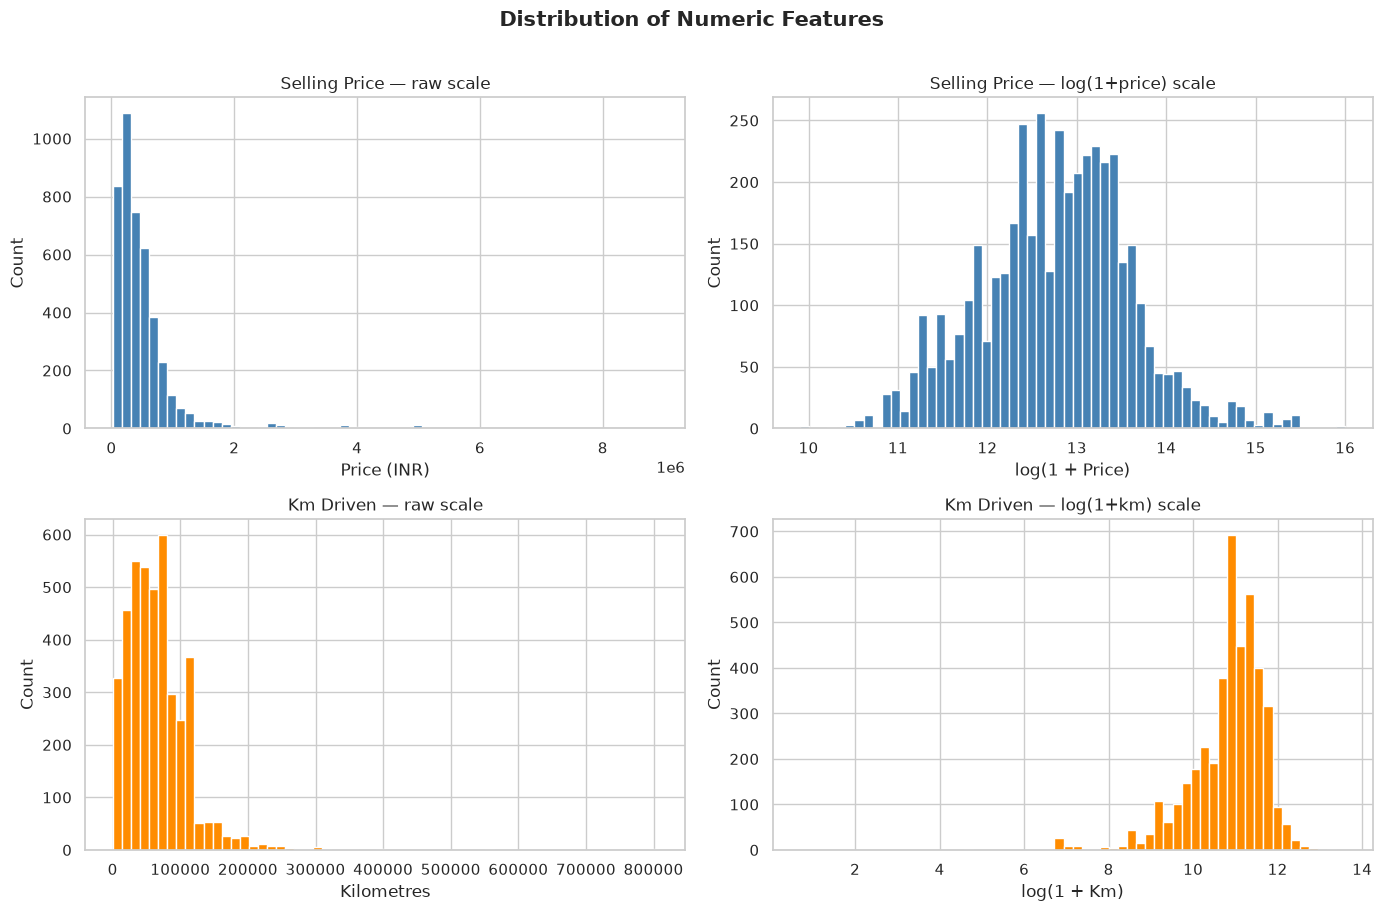

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribution of Numeric Features', fontsize=15, fontweight='bold', y=1.01)

axes[0,0].hist(df['selling_price'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Selling Price — raw scale')
axes[0,0].set_xlabel('Price (INR)')
axes[0,0].set_ylabel('Count')

axes[0,1].hist(np.log1p(df['selling_price']), bins=60, color='steelblue', edgecolor='white')
axes[0,1].set_title('Selling Price — log(1+price) scale')
axes[0,1].set_xlabel('log(1 + Price)')
axes[0,1].set_ylabel('Count')

axes[1,0].hist(df['km_driven'], bins=60, color='darkorange', edgecolor='white')
axes[1,0].set_title('Km Driven — raw scale')
axes[1,0].set_xlabel('Kilometres')
axes[1,0].set_ylabel('Count')

axes[1,1].hist(np.log1p(df['km_driven']), bins=60, color='darkorange', edgecolor='white')
axes[1,1].set_title('Km Driven — log(1+km) scale')
axes[1,1].set_xlabel('log(1 + Km)')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Interpretation

**Selling Price (raw):** Heavily **right-skewed** — the bulk of cars cluster below 1M INR, but a thin tail extends to 8-10M. A handful of premium cars could disproportionately affect RMSE.

**Selling Price (log scale):** After log-transformation the distribution becomes near-normal — bell-shaped and symmetric. This confirms the target follows a **log-normal distribution**, typical for price data.

**Km Driven (raw):** Similar right skew. Most cars have driven 20,000-100,000 km; extreme outliers exceed 500,000 km.

**Km Driven (log scale):** Becomes roughly symmetric after log-transform.

> **Practical implication:** Linear Regression and SVR will struggle with raw-scale skew. Tree-based models (Random Forest, XGBoost) are unaffected by monotonic transformations, so we leave the features on their original scale and let StandardScaler handle normalization.


---
## 4. Box Plots — Outlier Detection

Box plots visualize the **IQR** and flag points beyond the whiskers as potential outliers.

- **Box** = Q1 to Q3 (middle 50% of data)
- **Line inside** = median
- **Whiskers** extend to 1.5 x IQR
- **Points beyond whiskers** = flagged outliers


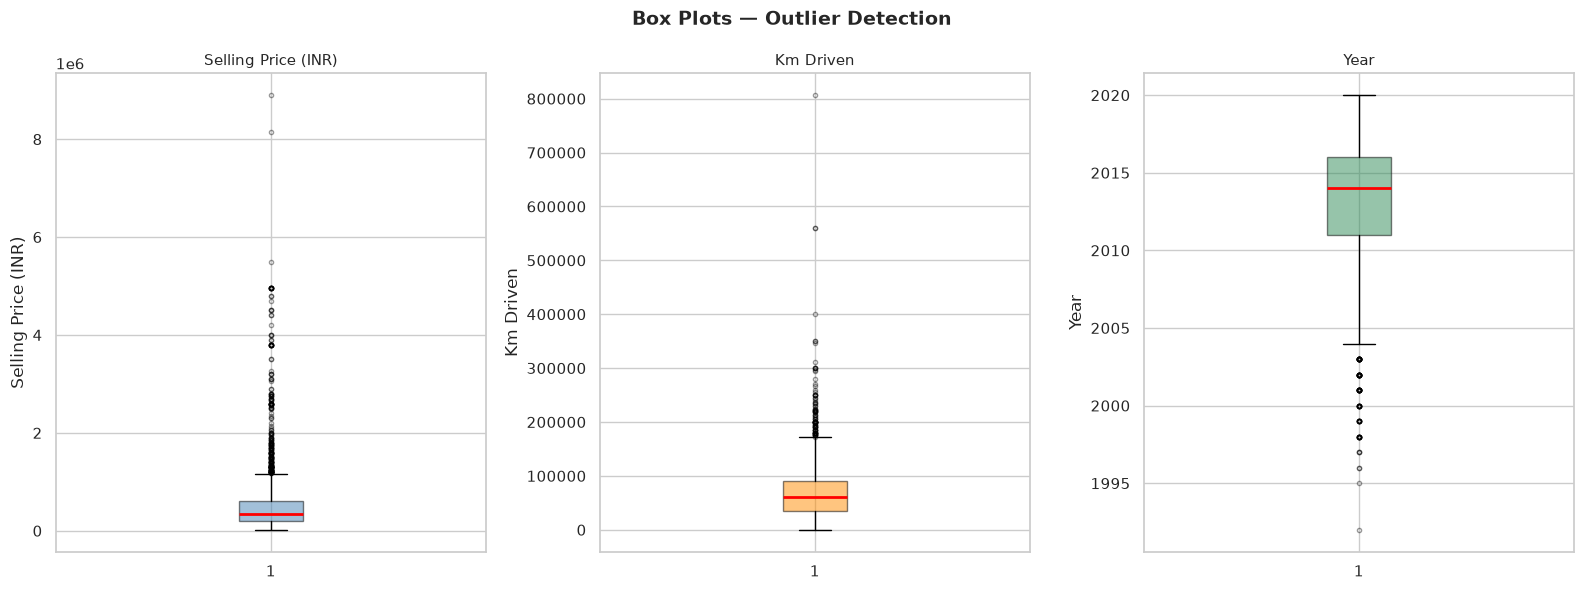


IQR-based bounds (1.5x and 3.0x IQR):
  selling_price    flag > [-378,126, 1,186,875]  remove > [-965,001, 1,773,751]
  km_driven        flag > [-47,500, 172,500]  remove > [-130,000, 255,000]
  year             flag > [2,004, 2,024]  remove > [1,996, 2,031]


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold')

plot_info = [
    ('selling_price', 'steelblue',  'Selling Price (INR)'),
    ('km_driven',     'darkorange', 'Km Driven'),
    ('year',          'seagreen',   'Year'),
]

for ax, (col, color, label) in zip(axes, plot_info):
    ax.boxplot(
        df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.5),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.4, color='gray'),
    )
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

print('\nIQR-based bounds (1.5x and 3.0x IQR):')
for col in ['selling_price', 'km_driven', 'year']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    print(f'  {col:15s}  flag > [{q1-1.5*iqr:,.0f}, {q3+1.5*iqr:,.0f}]  remove > [{q1-3.0*iqr:,.0f}, {q3+3.0*iqr:,.0f}]')


### Interpretation & handling strategy

| Variable | Observation | Decision |
|---|---|---|
| `selling_price` | Many points above the whisker — the used-car market genuinely includes high-value luxury cars. | **Keep moderate outliers** (within 3x IQR): plausible premium cars. **Remove extreme outliers** (beyond 3x IQR): likely data errors. |
| `km_driven` | A cluster of very high-mileage listings (commercial/taxi use). | Same policy: keep moderate, remove extreme. |
| `year` | A few very old cars (pre-1990) and future-dated entries are implausible. | **Remove** cars outside [1990, current_year] as impossible values. |

> **Why not remove all outliers?** A luxury SUV at 5M INR and a beat-up sedan at 150K INR are *both* real listings. Removing everything beyond 1.5x IQR would bias the model toward mid-range cars only, making it useless for platform-wide pricing.


In [7]:
from scipy import stats

print('Z-score > 3 counts per column:')
for col in ['selling_price', 'km_driven', 'year']:
    z = np.abs(stats.zscore(df[col].dropna()))
    n = (z > 3).sum()
    print(f'  {col:15s}  {n:>4d} rows  ({n/len(df)*100:.2f}%)')


Z-score > 3 counts per column:
  selling_price      92 rows  (2.12%)
  km_driven          51 rows  (1.18%)
  year               41 rows  (0.94%)


Z-score > 3 on `selling_price` and `km_driven` is expected given the right skew. These results align with the IQR findings and confirm that both methods are targeting the same extreme cases.


---
## 5. Correlation Heatmap

The Pearson correlation coefficient measures **linear** relationships between numeric variables.
Values range from -1 (perfect negative) to +1 (perfect positive); 0 = no linear relationship.


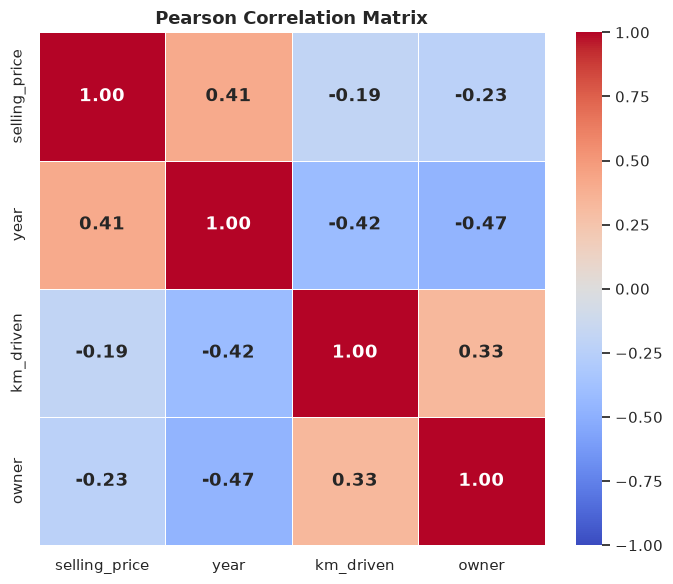

In [8]:
owner_map = {'Test Drive Car':0,'First Owner':1,'Second Owner':2,'Third Owner':3,'Fourth & Above Owner':4}
df_corr = df.copy()
df_corr['owner'] = df_corr['owner'].map(owner_map)

corr = df_corr[['selling_price','year','km_driven','owner']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'},
)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Reading the heatmap

| Pair | Correlation | Interpretation |
|---|---|---|
| `year` vs `selling_price` | **Strong positive** | Newer cars sell for more. Year is likely the **strongest single predictor**. |
| `km_driven` vs `selling_price` | **Moderate negative** | More mileage = lower resale value. Confirms km_driven is a useful feature. |
| `owner` vs `selling_price` | **Moderate negative** | More previous owners = lower price — makes intuitive sense. |
| `km_driven` vs `year` | **Moderate negative** | Older cars have been driven more — natural collinearity. Not a problem for tree-based models. |

> **Note:** Pearson only captures **linear** relationships. Tree-based models can capture non-linear patterns too (e.g., price drops sharply after a mileage threshold), so low Pearson correlation does not necessarily mean a feature is unhelpful.


---
## 6. Pairplot — Feature Interactions

A pairplot shows **every pair of numeric variables** as a scatter plot, with KDE density curves on the diagonal.
This reveals non-linear relationships that the heatmap misses.


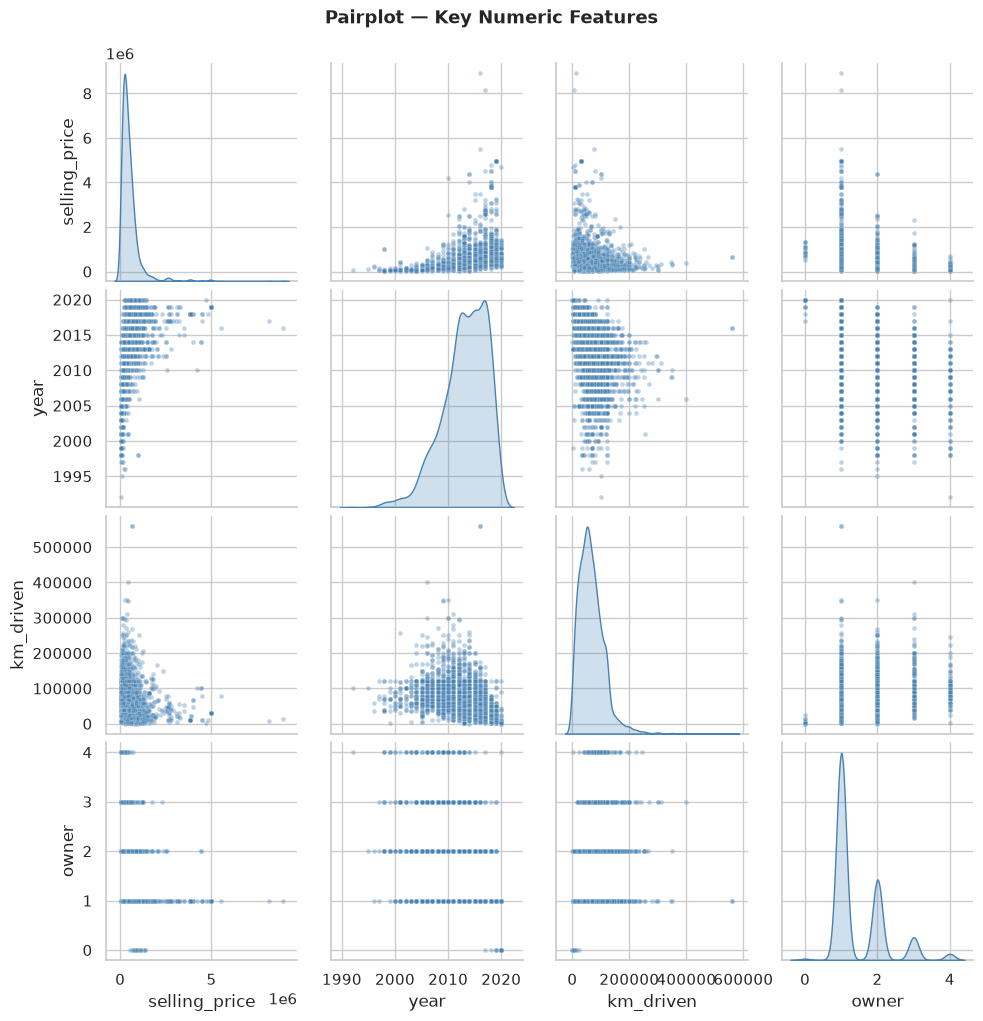

In [9]:
owner_map = {'Test Drive Car':0,'First Owner':1,'Second Owner':2,'Third Owner':3,'Fourth & Above Owner':4}
df_pair = df[['selling_price','year','km_driven','owner']].copy()
df_pair['owner'] = df['owner'].map(owner_map)

g = sns.pairplot(
    df_pair.dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 12, 'color': 'steelblue'},
    diag_kws={'color': 'steelblue', 'fill': True},
    height=2.5,
)
g.figure.suptitle('Pairplot — Key Numeric Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()


### What to look for in a pairplot

**Diagonal (KDE):**
- `selling_price` — confirms right skew; most cars cluster low with a long tail
- `km_driven` — similar right skew
- `year` — roughly bell-shaped; most cars are 5-15 years old
- `owner` — discrete distribution (1, 2, 3, 4)

**Off-diagonal scatter plots:**
- `year` vs `selling_price` — visible upward trend: newer = more expensive; possible non-linearity at the extremes
- `km_driven` vs `selling_price` — downward trend with large spread
- `owner` vs `selling_price` — step-like pattern: First Owner cars clearly command higher prices
- `km_driven` vs `year` — negative trend: older cars have more km (as expected)

> **Key insight:** The relationships are **not perfectly linear** — a tree-based model that can learn thresholds will outperform Linear Regression here. This is why Random Forest and XGBoost are our primary candidates.


---
## 7. Price by Categorical Feature

Violin plots show how `selling_price` varies across each category.
They directly answer: *Does this categorical variable have a meaningful impact on price?*


/tmp/ipykernel_165901/2270324422.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_165901/2270324422.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_165901/2270324422.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


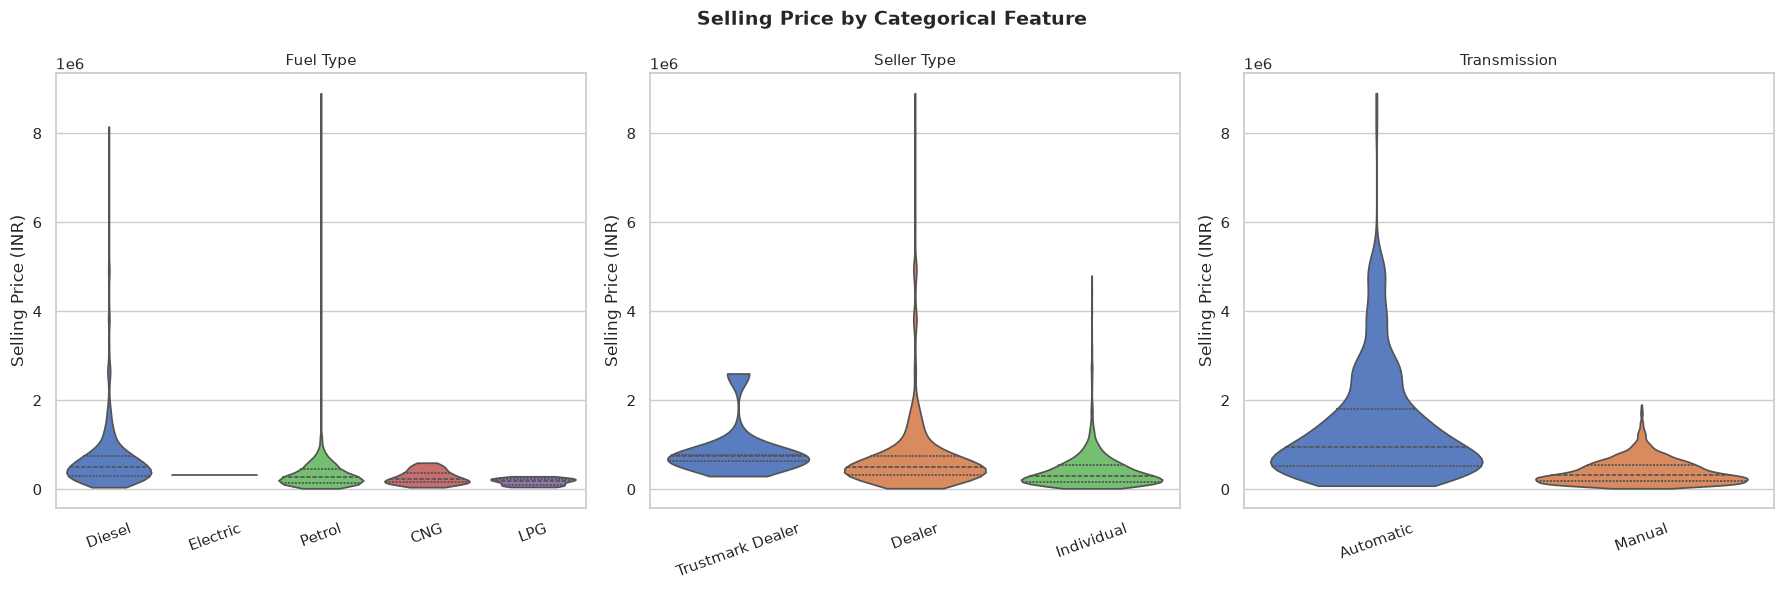

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Selling Price by Categorical Feature', fontsize=14, fontweight='bold')

cat_plots = [
    ('fuel',         'Fuel Type'),
    ('seller_type',  'Seller Type'),
    ('transmission', 'Transmission'),
]

for ax, (col, title) in zip(axes, cat_plots):
    order = df.groupby(col)['selling_price'].median().sort_values(ascending=False).index
    sns.violinplot(
        data=df, x=col, y='selling_price', ax=ax,
        order=order, inner='quartile', palette='muted', cut=0,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Selling Price (INR)')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### Interpretation — why each category stays in the model

**Fuel type:** Diesel and Electric cars show higher median prices and wider spread. CNG/LPG are budget segments. Clear price stratification confirms `fuel` is a **meaningful feature**.

**Seller type:** Trustmark Dealer > Dealer > Individual in median price. Dealers price higher (margin, warranty, reconditioning). The pattern is consistent — **justifies keeping this feature**.

**Transmission:** Automatic cars command a significant median premium over Manual. In the Indian market this premium is well-documented. **Clear signal — keep the feature**.


---
## 8. Column Relevance Justification

Based on all analyses above, here is the formal justification for each column's treatment:

| Column | Decision | Justification |
|---|---|---|
| `year` | **KEEP** | Strongest numeric predictor — newer cars sell for significantly more. Confirmed by heatmap, pairplot, and business logic. |
| `km_driven` | **KEEP** | Direct proxy for wear and remaining lifespan. Negatively correlated with price. |
| `fuel` | **KEEP** | Clear price stratification across fuel types. Diesel/Electric premium is real and consistent. |
| `seller_type` | **KEEP** | Dealers price systematically higher. Captures a market-structure effect the model would otherwise miss. |
| `transmission` | **KEEP** | Automatic cars carry a measurable premium. Binary encoding (Manual=0, Automatic=1) is sufficient. |
| `owner` | **KEEP** | Ordinal variable — more previous owners depresses price. Integer encoding (1-4) preserves the natural ordering. |
| `name` | **DROP** | Free-text car model name with hundreds of unique values. Not encodable without a separate embedding step — would cause extreme sparsity or data leakage. |
| `selling_price` | **TARGET** | What we want to predict. Never used as a feature (data leakage would make model useless in production). |


---
## 9. EDA Summary — Key Findings

| Finding | Implication for modeling |
|---|---|
| `selling_price` is right-skewed (log-normal) | RMSE will be sensitive to expensive car errors; track MAE alongside RMSE |
| `km_driven` is right-skewed | StandardScaler reduces impact; tree models are unaffected |
| `year` is the strongest numeric predictor | Expect it near the top of feature importance rankings |
| All categorical features show price stratification | One-hot (fuel, seller_type) and binary (transmission) encodings are justified |
| Moderate collinearity between `km_driven` and `year` | Not a problem for tree models; mild concern for Linear Regression / SVR |
| Outliers exist in price and mileage | Extreme outliers (> 3x IQR) removed; moderate ones kept as real market data |

**Next step:** `cleaning.py` handles missing values, duplicates, and applies the outlier strategy above. Then `preprocessing.py` for encoding and StandardScaler.
